# Benchmark: PyTorch vs ONNX vs OpenVINO
Сравнение форматов по **скорости** (ms/кадр) и **качеству** (IoU боксов, согласованность классов, уверенность).

Все три модели проекта: **BestBoots_v2** (детекция колёс), **person** (детекция людей), **BestPose** (скелетная поза).

In [14]:
import os, time, warnings
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from ultralytics import YOLO

warnings.filterwarnings('ignore')

# ── Пути ────────────────────────────────────────────────────────────────────
BASE   = Path(r'C:\Users\shche\Desktop\Application_for_models\models')
VIDEO  = Path(r'C:\Users\shche\Desktop\Application_for_models\137826-video.h264 (online-video-cutter.com).mp4')

MODELS = {
    'BestBoots_v2': {
        'pt':       BASE / 'BestBoots_v2.pt',
        'onnx':     BASE / 'BestBoots_v2.onnx',
        'openvino': BASE / 'BestBoots_v2_openvino_model',
    },
    'person': {
        'pt':       BASE / 'person.pt',
        'onnx':     BASE / 'person.onnx',
        'openvino': BASE / 'person_openvino_model',
    },
    'BestPose': {
        'pt':       BASE / 'BestPose.pt',
        'onnx':     BASE / 'BestPose.onnx',
        'openvino': BASE / 'BestPose_openvino_model',
    },
}

N_FRAMES  = 80   # кадров для бенчмарка
N_WARMUP  = 8    # прогрев (не считаем)
CONF      = 0.25

print('Video:', VIDEO.name)
print('Models base:', BASE)

Video: 137826-video.h264 (online-video-cutter.com).mp4
Models base: C:\Users\shche\Desktop\Application_for_models\models


In [15]:
# ── Читаем N_FRAMES равномерно распределённых кадров ────────────────────────
def sample_frames(path, n):
    cap   = cv2.VideoCapture(str(path))
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps   = cap.get(cv2.CAP_PROP_FPS)
    w, h  = int(cap.get(3)), int(cap.get(4))
    step  = max(1, total // n)
    frames, idx = [], 0
    while cap.isOpened() and len(frames) < n:
        ret, frame = cap.read()
        if not ret: break
        if idx % step == 0:
            frames.append(frame)
        idx += 1
    cap.release()
    print(f'Loaded {len(frames)} frames  ({w}x{h}, {total} total, {fps:.0f} fps)')
    return frames[:n]

frames = sample_frames(VIDEO, N_FRAMES + N_WARMUP)

Loaded 88 frames  (2688x1520, 760 total, 25 fps)


In [16]:
# ── Получить нативный imgsz из OpenVINO XML ──────────────────────────────────
def native_imgsz(model_path):
    p = Path(model_path)
    # ONNX
    if p.suffix.lower() == '.onnx':
        try:
            import onnxruntime as ort
            sess  = ort.InferenceSession(str(p), providers=['CPUExecutionProvider'])
            shape = sess.get_inputs()[0].shape
            h = shape[2] if len(shape) >= 4 else None
            if isinstance(h, int) and h > 0:
                return h
        except Exception:
            pass
        return 640
    # OpenVINO directory
    xml_dir = p if p.is_dir() else p.parent
    meta = xml_dir / 'metadata.yaml'
    if meta.exists():
        import yaml
        with open(meta) as f:
            m = yaml.safe_load(f)
        imgsz = m.get('imgsz', 640)
        if isinstance(imgsz, (list, tuple)): return int(imgsz[0])
        return int(imgsz)
    # Fallback: read from OpenVINO model
    try:
        import openvino as ov
        xmls = list(xml_dir.glob('*.xml'))
        if xmls:
            m = ov.Core().read_model(str(xmls[0]))
            s = m.input().shape
            if len(s) >= 4: return int(s[2])
    except Exception:
        pass
    return 640

In [17]:
# ── IoU вспомогательная функция ──────────────────────────────────────────────
def box_iou(a, b):
    """IoU between two boxes [x1,y1,x2,y2]."""
    xi1 = max(a[0], b[0]); yi1 = max(a[1], b[1])
    xi2 = min(a[2], b[2]); yi2 = min(a[3], b[3])
    inter = max(0, xi2-xi1) * max(0, yi2-yi1)
    au = (a[2]-a[0])*(a[3]-a[1])
    bu = (b[2]-b[0])*(b[3]-b[1])
    union = au + bu - inter
    return inter / union if union > 0 else 0.0

def compare_to_pt(res_pt, res_other):
    """
    Сравниваем результаты «другого» формата с PT (эталон).
    Возвращает: mean_iou, conf_delta, class_agree, recall, precision
    """
    iou_list, conf_delta, cls_agree = [], [], []
    tp = fp = fn = 0

    for r_pt, r_oth in zip(res_pt, res_other):
        b_pt  = r_pt.boxes
        b_oth = r_oth.boxes

        boxes_pt  = b_pt.xyxy.cpu().numpy()  if b_pt  is not None and len(b_pt)  else np.zeros((0,4))
        boxes_oth = b_oth.xyxy.cpu().numpy() if b_oth is not None and len(b_oth) else np.zeros((0,4))
        cls_pt  = b_pt.cls.cpu().numpy().astype(int)  if b_pt  is not None and len(b_pt)  else np.array([])
        cls_oth = b_oth.cls.cpu().numpy().astype(int) if b_oth is not None and len(b_oth) else np.array([])
        conf_oth = b_oth.conf.cpu().numpy() if b_oth is not None and len(b_oth) else np.array([])
        conf_pt  = b_pt.conf.cpu().numpy()  if b_pt  is not None and len(b_pt)  else np.array([])

        matched_oth = set()
        for i, bp in enumerate(boxes_pt):
            best_iou, best_j = 0, -1
            for j, bo in enumerate(boxes_oth):
                if j in matched_oth: continue
                iou = box_iou(bp, bo)
                if iou > best_iou:
                    best_iou, best_j = iou, j
            if best_j >= 0 and best_iou > 0.4:
                matched_oth.add(best_j)
                iou_list.append(best_iou)
                tp += 1
                c_pt  = conf_pt[i]  if i  < len(conf_pt)  else 0
                c_oth = conf_oth[best_j] if best_j < len(conf_oth) else 0
                conf_delta.append(abs(c_pt - c_oth))
                if i < len(cls_pt) and best_j < len(cls_oth):
                    cls_agree.append(int(cls_pt[i] == cls_oth[best_j]))
            else:
                fn += 1
        fp += len(boxes_oth) - len(matched_oth)

    total_pt = tp + fn
    recall    = tp / total_pt if total_pt > 0 else 1.0
    precision = tp / (tp + fp) if (tp + fp) > 0 else 1.0
    return {
        'mean_iou':    float(np.mean(iou_list))   if iou_list   else 1.0,
        'conf_delta':  float(np.mean(conf_delta)) if conf_delta else 0.0,
        'class_agree': float(np.mean(cls_agree))  if cls_agree  else 1.0,
        'recall':      recall,
        'precision':   precision,
    }

print('Helper functions ready.')

Helper functions ready.


In [18]:
# ── Основной бенчмарк ────────────────────────────────────────────────────────
def run_benchmark(model_name, paths, frames_all):
    results_by_fmt = {}
    speed_by_fmt   = {}

    for fmt, path in paths.items():
        if not Path(str(path)).exists():
            print(f'  [{fmt}] SKIP — not found: {path}')
            continue

        print(f'  Loading [{fmt}]...', end=' ', flush=True)
        model  = YOLO(str(path))
        imgsz  = native_imgsz(path) if fmt != 'pt' else 640
        print(f'imgsz={imgsz}', end=' ')

        # прогрев
        for f in frames_all[:N_WARMUP]:
            model(f, imgsz=imgsz, conf=CONF, verbose=False, half=False)

        # замер
        times, preds = [], []
        for f in frames_all[N_WARMUP:]:
            t0 = time.perf_counter()
            res = model(f, imgsz=imgsz, conf=CONF, verbose=False, half=False)
            times.append((time.perf_counter() - t0) * 1000)
            preds.append(res[0])

        mean_ms = float(np.mean(times))
        p95_ms  = float(np.percentile(times, 95))
        print(f'→ {mean_ms:.1f} ms/frame  (p95={p95_ms:.0f} ms)')

        results_by_fmt[fmt] = preds
        speed_by_fmt[fmt]   = {'mean_ms': mean_ms, 'p95_ms': p95_ms,
                                'fps': 1000/mean_ms, 'times': times}

    return results_by_fmt, speed_by_fmt


all_results = {}   # model_name → {fmt → [Results]}
all_speed   = {}   # model_name → {fmt → speed_dict}

for mname, paths in MODELS.items():
    print(f'\n=== {mname} ===')
    r, s = run_benchmark(mname, paths, frames)
    all_results[mname] = r
    all_speed[mname]   = s

print('\n✓ Benchmark done.')


=== BestBoots_v2 ===
  Loading [pt]... imgsz=640 → 58.5 ms/frame  (p95=80 ms)
  Loading [onnx]... WARNING Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
imgsz=640 Loading C:\Users\shche\Desktop\Application_for_models\models\BestBoots_v2.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.24.1 with CPUExecutionProvider
→ 76.7 ms/frame  (p95=96 ms)
  Loading [openvino]... WARNING Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
imgsz=640 Loading C:\Users\shche\Desktop\Application_for_models\models\BestBoots_v2_openvino_model for OpenVINO inference...
Using OpenVINO LATENCY mode for batch=1 inference on (CPU)...
→ 146.2 ms/frame  (p95=276 ms)

=== person ===
  Loading [pt]... imgsz=640 → 53.7 ms/frame  (p95=61 ms)
  Loading [onnx]... WARNING Unable to auto

In [19]:
# ── Считаем метрики качества (сравнение с PT как эталоном) ──────────────────
quality_rows = []

for mname, results in all_results.items():
    if 'pt' not in results:
        print(f'[{mname}] No PT results — skip quality comparison')
        continue
    for fmt, preds in results.items():
        speed = all_speed[mname][fmt]
        if fmt == 'pt':
            q = {'mean_iou': 1.0, 'conf_delta': 0.0, 'class_agree': 1.0,
                 'recall': 1.0, 'precision': 1.0}
        else:
            q = compare_to_pt(results['pt'], preds)
        quality_rows.append({
            'Model':      mname,
            'Format':     fmt,
            'Mean ms':    round(speed['mean_ms'], 1),
            'FPS':        round(speed['fps'], 1),
            'p95 ms':     round(speed['p95_ms'], 1),
            'IoU vs PT':  round(q['mean_iou'],    3),
            'Conf Δ':     round(q['conf_delta'],  3),
            'Class agree':round(q['class_agree'], 3),
            'Recall':     round(q['recall'],      3),
            'Precision':  round(q['precision'],   3),
        })

df = pd.DataFrame(quality_rows)

# Composite quality score: 0-100
# IoU (40%), Recall (25%), Class agree (20%), 1-ConfDelta (10%), Precision (5%)
df['Quality'] = (
    df['IoU vs PT']   * 40 +
    df['Recall']      * 25 +
    df['Class agree'] * 20 +
    (1 - df['Conf Δ'].clip(0, 1)) * 10 +
    df['Precision']   * 5
).round(1)

# Speed/Quality score: FPS * Quality/100
df['Speed×Quality'] = (df['FPS'] * df['Quality'] / 100).round(2)

print(df.to_string(index=False))

       Model   Format  Mean ms  FPS  p95 ms  IoU vs PT  Conf Δ  Class agree  Recall  Precision  Quality  Speed×Quality
BestBoots_v2       pt     58.5 17.1    79.6      1.000   0.000          1.0   1.000      1.000    100.0          17.10
BestBoots_v2     onnx     76.7 13.0    96.2      0.972   0.042          1.0   0.959      0.940     97.1          12.62
BestBoots_v2 openvino    146.2  6.8   276.3      0.972   0.042          1.0   0.959      0.940     97.1           6.60
      person       pt     53.7 18.6    60.7      1.000   0.000          1.0   1.000      1.000    100.0          18.60
      person     onnx     77.6 12.9    80.0      0.981   0.020          1.0   0.918      0.957     96.8          12.49
      person openvino    114.9  8.7   322.1      0.972   0.020          1.0   0.918      0.937     96.3           8.38
    BestPose       pt     69.7 14.3    87.3      1.000   0.000          1.0   1.000      1.000    100.0          14.30
    BestPose     onnx     79.4 12.6    93.4     

In [20]:
# ── Таблица результатов ──────────────────────────────────────────────────────
display_cols = ['Model','Format','Mean ms','FPS','p95 ms',
                'IoU vs PT','Recall','Class agree','Quality','Speed×Quality']

def color_fmt(val):
    colors = {'pt': '#4a90d9', 'onnx': '#f5a623', 'openvino': '#7ed321'}
    return f'background-color: {colors.get(val, "white")}; color: black'

def color_val(val, vmin, vmax, good_high=True):
    if pd.isna(val): return ''
    t = (val - vmin) / (vmax - vmin + 1e-9)
    if not good_high: t = 1 - t
    r = int(255 * (1 - t))
    g = int(200 * t)
    return f'background-color: rgb({r},{g},80)'

styled = df[display_cols].style \
    .applymap(color_fmt, subset=['Format']) \
    .background_gradient(subset=['FPS','Quality','Speed×Quality'], cmap='RdYlGn') \
    .background_gradient(subset=['Mean ms','p95 ms'], cmap='RdYlGn_r') \
    .background_gradient(subset=['IoU vs PT','Recall','Class agree'], cmap='RdYlGn') \
    .set_caption('Benchmark: PT vs ONNX vs OpenVINO') \
    .format({'Mean ms':'{:.1f}','FPS':'{:.1f}','p95 ms':'{:.1f}',
             'IoU vs PT':'{:.3f}','Recall':'{:.3f}','Class agree':'{:.3f}',
             'Quality':'{:.1f}','Speed×Quality':'{:.2f}'})

display(styled)

,Model,Format,Mean ms,FPS,p95 ms,IoU vs PT,Recall,Class agree,Quality,Speed×Quality
0,BestBoots_v2,pt,58.5,17.1,79.6,1.000,1.000,1.000,100.0,17.10
1,BestBoots_v2,onnx,76.7,13.0,96.2,0.972,0.959,1.000,97.1,12.62
2,BestBoots_v2,openvino,146.2,6.8,276.3,0.972,0.959,1.000,97.1,6.60
3,person,pt,53.7,18.6,60.7,1.000,1.000,1.000,100.0,18.60
4,person,onnx,77.6,12.9,80.0,0.981,0.918,1.000,96.8,12.49
5,person,openvino,114.9,8.7,322.1,0.972,0.918,1.000,96.3,8.38
6,BestPose,pt,69.7,14.3,87.3,1.000,1.000,1.000,100.0,14.30
7,BestPose,onnx,79.4,12.6,93.4,0.995,1.000,1.000,99.5,12.54
8,BestPose,openvino,153.7,6.5,336.2,0.994,1.000,1.000,99.5,6.47


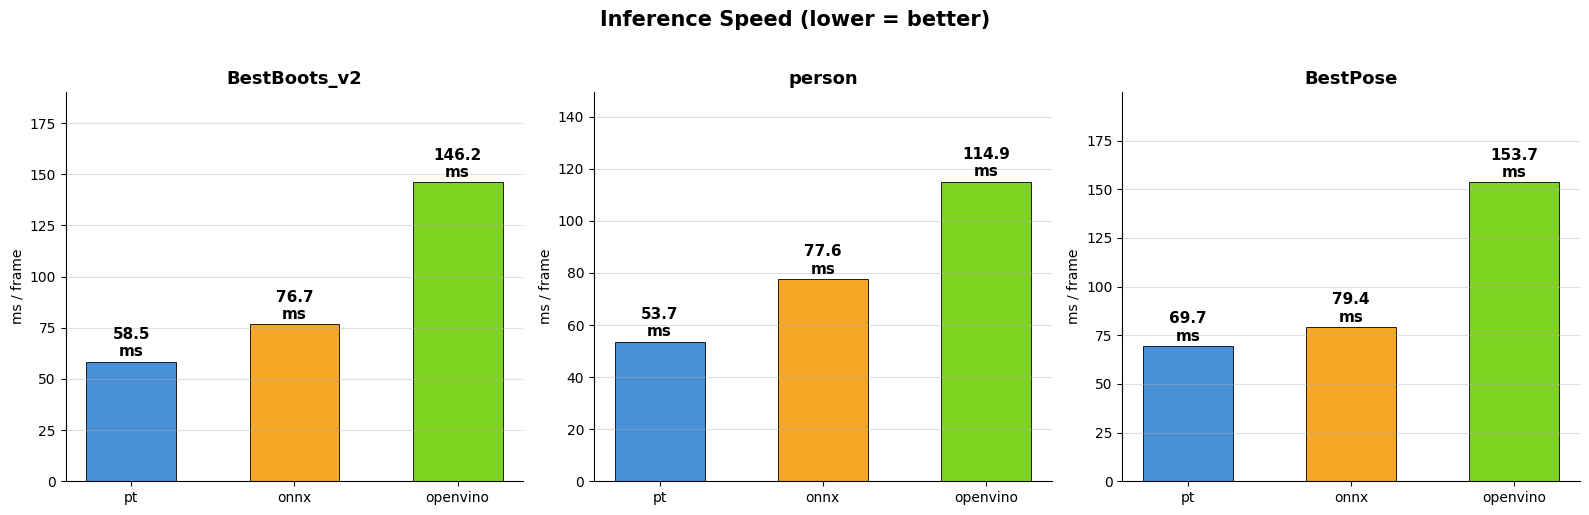

In [21]:
# ── График 1: Скорость (ms/frame) по моделям и форматам ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fmt_colors = {'pt': '#4a90d9', 'onnx': '#f5a623', 'openvino': '#7ed321'}
fmt_order  = ['pt', 'onnx', 'openvino']

for ax, mname in zip(axes, MODELS.keys()):
    spd = all_speed.get(mname, {})
    fmts = [f for f in fmt_order if f in spd]
    vals = [spd[f]['mean_ms'] for f in fmts]
    bars = ax.bar(fmts, vals,
                  color=[fmt_colors[f] for f in fmts],
                  edgecolor='black', linewidth=0.6, width=0.55)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{v:.1f}\nms', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_title(mname, fontsize=13, fontweight='bold')
    ax.set_ylabel('ms / frame')
    ax.set_ylim(0, max(vals)*1.3)
    ax.grid(axis='y', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Inference Speed (lower = better)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('benchmark_speed.png', dpi=130, bbox_inches='tight')
plt.show()

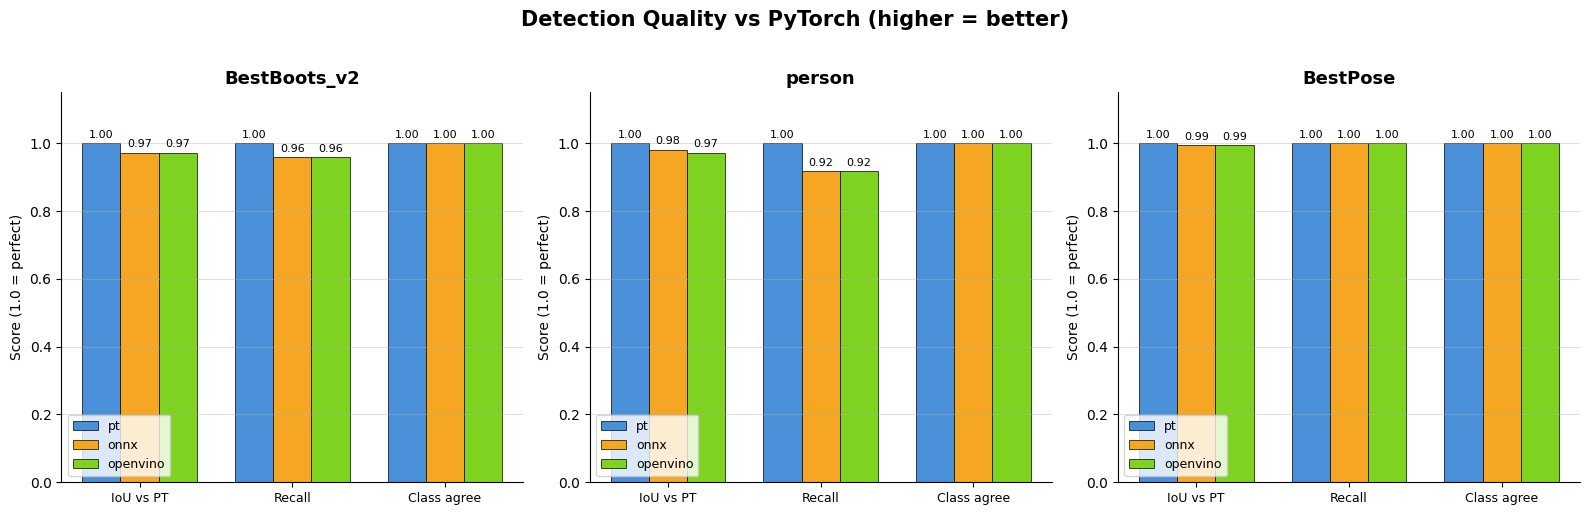

In [22]:
# ── График 2: Качество (IoU, Recall, Class agree) ────────────────────────────
metrics = ['IoU vs PT', 'Recall', 'Class agree']
model_names = list(MODELS.keys())

fig, axes = plt.subplots(1, len(model_names), figsize=(16, 5))

for ax, mname in zip(axes, model_names):
    sub = df[df['Model'] == mname]
    fmts = sub['Format'].tolist()
    x = np.arange(len(metrics))
    width = 0.25
    for i, (_, row) in enumerate(sub.iterrows()):
        fmt = row['Format']
        vals = [row[m] for m in metrics]
        bars = ax.bar(x + i*width, vals, width,
                      label=fmt, color=fmt_colors.get(fmt, 'gray'),
                      edgecolor='black', linewidth=0.5)
        for b, v in zip(bars, vals):
            ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.01,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(mname, fontsize=13, fontweight='bold')
    ax.set_xticks(x + width)
    ax.set_xticklabels(metrics, fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score (1.0 = perfect)')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Detection Quality vs PyTorch (higher = better)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('benchmark_quality.png', dpi=130, bbox_inches='tight')
plt.show()

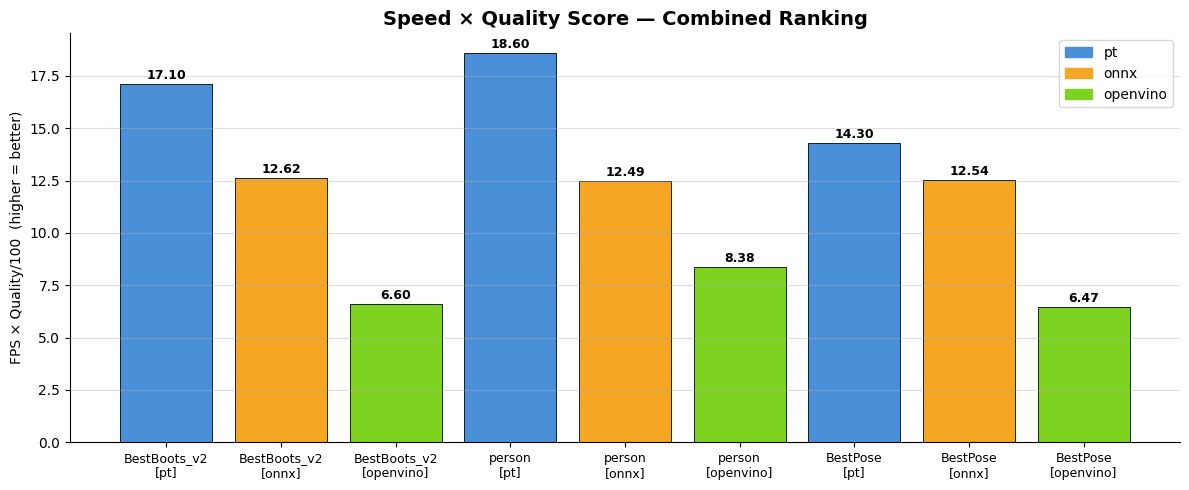

In [23]:
# ── График 3: Speed × Quality — главный рейтинг ──────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

bar_labels = [f"{r['Model']}\n[{r['Format']}]" for _, r in df.iterrows()]
bar_vals   = df['Speed×Quality'].tolist()
bar_colors = [fmt_colors.get(r['Format'], 'gray') for _, r in df.iterrows()]

bars = ax.bar(range(len(bar_vals)), bar_vals, color=bar_colors,
              edgecolor='black', linewidth=0.6)

for bar, v in zip(bars, bar_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
            f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(range(len(bar_labels)))
ax.set_xticklabels(bar_labels, fontsize=9)
ax.set_ylabel('FPS × Quality/100  (higher = better)')
ax.set_title('Speed × Quality Score — Combined Ranking', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_patches = [mpatches.Patch(color=c, label=f) for f, c in fmt_colors.items()]
ax.legend(handles=legend_patches, fontsize=10)

plt.tight_layout()
plt.savefig('benchmark_combined.png', dpi=130, bbox_inches='tight')
plt.show()

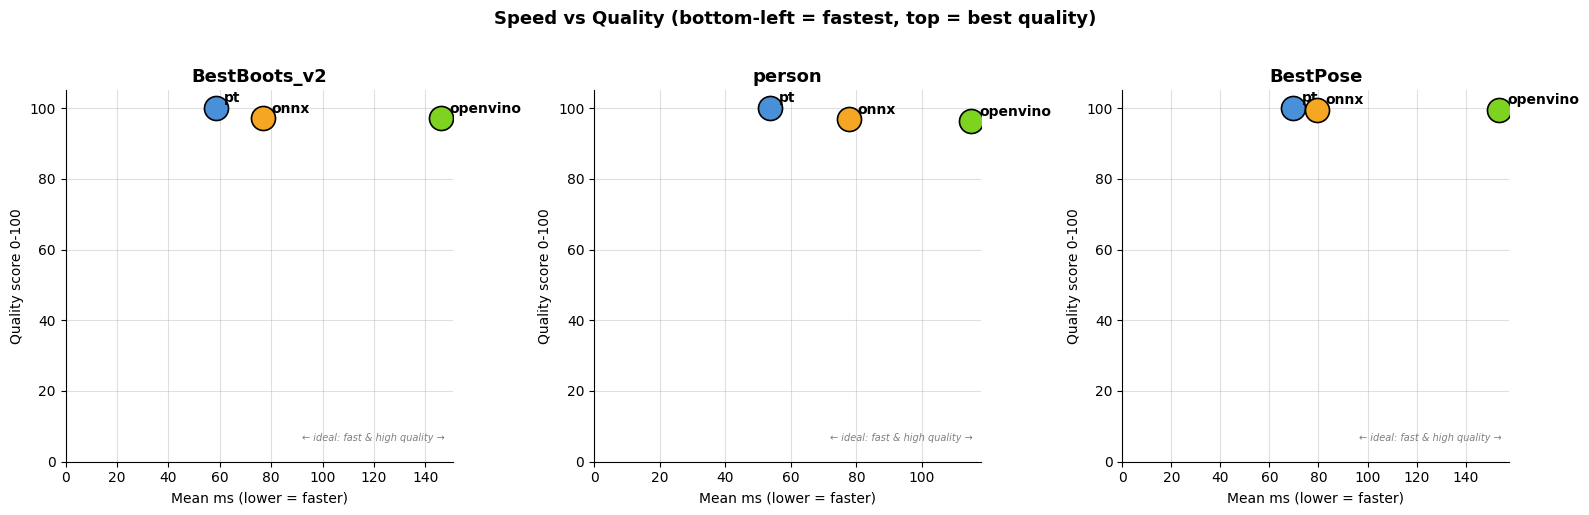

In [24]:
# ── График 4: Scatter — Speed vs Quality (пузырьковый) ───────────────────────
fig, axes = plt.subplots(1, len(model_names), figsize=(16, 5))

for ax, mname in zip(axes, model_names):
    sub = df[df['Model'] == mname]
    for _, row in sub.iterrows():
        fmt = row['Format']
        ax.scatter(row['Mean ms'], row['Quality'],
                   s=300, color=fmt_colors.get(fmt, 'gray'),
                   edgecolors='black', linewidths=1.2, zorder=3)
        ax.annotate(fmt, (row['Mean ms'], row['Quality']),
                    textcoords='offset points', xytext=(6, 4),
                    fontsize=10, fontweight='bold')
    ax.set_xlabel('Mean ms (lower = faster)', fontsize=10)
    ax.set_ylabel('Quality score 0-100', fontsize=10)
    ax.set_title(mname, fontsize=13, fontweight='bold')
    ax.set_xlim(left=0)
    ax.set_ylim(0, 105)
    ax.grid(alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # Ideal corner: bottom-right = fast+high quality
    ax.text(0.98, 0.05, '← ideal: fast & high quality →',
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=7, color='gray', style='italic')

fig.suptitle('Speed vs Quality (bottom-left = fastest, top = best quality)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('benchmark_scatter.png', dpi=130, bbox_inches='tight')
plt.show()

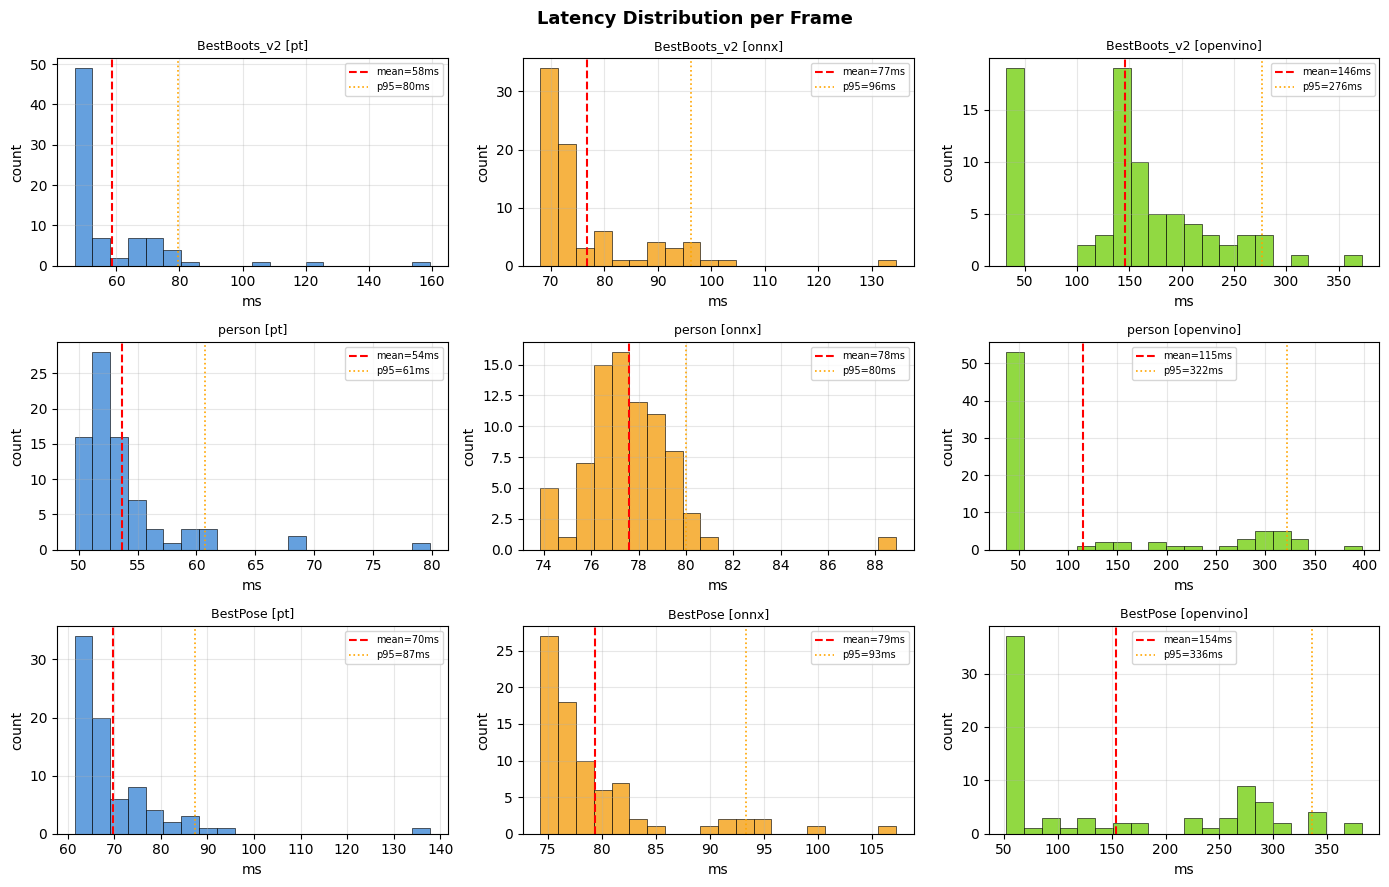

In [25]:
# ── Гистограммы задержки — распределение времён ──────────────────────────────
fig, axes = plt.subplots(len(model_names), 3, figsize=(14, 3*len(model_names)))

for row_i, mname in enumerate(model_names):
    spd = all_speed.get(mname, {})
    for col_i, fmt in enumerate(fmt_order):
        ax = axes[row_i][col_i]
        if fmt not in spd:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{mname} [{fmt}]')
            continue
        t = spd[fmt]['times']
        ax.hist(t, bins=20, color=fmt_colors[fmt], edgecolor='black',
                linewidth=0.5, alpha=0.85)
        ax.axvline(np.mean(t),  color='red',    linewidth=1.5, linestyle='--', label=f'mean={np.mean(t):.0f}ms')
        ax.axvline(np.percentile(t,95), color='orange', linewidth=1.2, linestyle=':', label=f'p95={np.percentile(t,95):.0f}ms')
        ax.set_title(f'{mname} [{fmt}]', fontsize=9)
        ax.set_xlabel('ms'); ax.set_ylabel('count')
        ax.legend(fontsize=7)
        ax.grid(alpha=0.3)

fig.suptitle('Latency Distribution per Frame', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('benchmark_latency_dist.png', dpi=130, bbox_inches='tight')
plt.show()

In [26]:
# ── Итоговый вывод ────────────────────────────────────────────────────────────
print('=' * 65)
print('  ИТОГОВЫЙ РЕЙТИНГ (Speed × Quality)')
print('=' * 65)

ranking = df.sort_values('Speed×Quality', ascending=False)
for rank, (_, row) in enumerate(ranking.iterrows(), 1):
    medal = ['🥇','🥈','🥉','  ','  ','  ','  ','  ','  '][rank-1]
    print(f'{medal} #{rank}  {row["Model"]:<18} [{row["Format"]:<9}]  '
          f'{row["Mean ms"]:>6.1f} ms  '
          f'{row["FPS"]:>5.1f} fps  '
          f'quality={row["Quality"]:>5.1f}/100  '
          f'score={row["Speed×Quality"]:>6.2f}')

print()
print('  По форматам (среднее по всем моделям):')
fmt_summary = df.groupby('Format').agg({'Mean ms':'mean','FPS':'mean','Quality':'mean','Speed×Quality':'mean'}).round(2)
print(fmt_summary.sort_values('Speed×Quality', ascending=False).to_string())

best_fmt = fmt_summary['Speed×Quality'].idxmax()
print(f'\n  ★ Лучший формат по соотношению скорость/качество: [{best_fmt.upper()}]')

best_overall = ranking.iloc[0]
print(f'  ★ Лучшая комбинация: {best_overall["Model"]} [{best_overall["Format"]}] — '
      f'{best_overall["FPS"]:.1f} fps, quality={best_overall["Quality"]:.1f}')

  ИТОГОВЫЙ РЕЙТИНГ (Speed × Quality)
🥇 #1  person             [pt       ]    53.7 ms   18.6 fps  quality=100.0/100  score= 18.60
🥈 #2  BestBoots_v2       [pt       ]    58.5 ms   17.1 fps  quality=100.0/100  score= 17.10
🥉 #3  BestPose           [pt       ]    69.7 ms   14.3 fps  quality=100.0/100  score= 14.30
   #4  BestBoots_v2       [onnx     ]    76.7 ms   13.0 fps  quality= 97.1/100  score= 12.62
   #5  BestPose           [onnx     ]    79.4 ms   12.6 fps  quality= 99.5/100  score= 12.54
   #6  person             [onnx     ]    77.6 ms   12.9 fps  quality= 96.8/100  score= 12.49
   #7  person             [openvino ]   114.9 ms    8.7 fps  quality= 96.3/100  score=  8.38
   #8  BestBoots_v2       [openvino ]   146.2 ms    6.8 fps  quality= 97.1/100  score=  6.60
   #9  BestPose           [openvino ]   153.7 ms    6.5 fps  quality= 99.5/100  score=  6.47

  По форматам (среднее по всем моделям):
          Mean ms    FPS  Quality  Speed×Quality
Format                                